Device → cuda (GPU)
Dataset chargé : 851,264 lignes | Action sample : WLTW


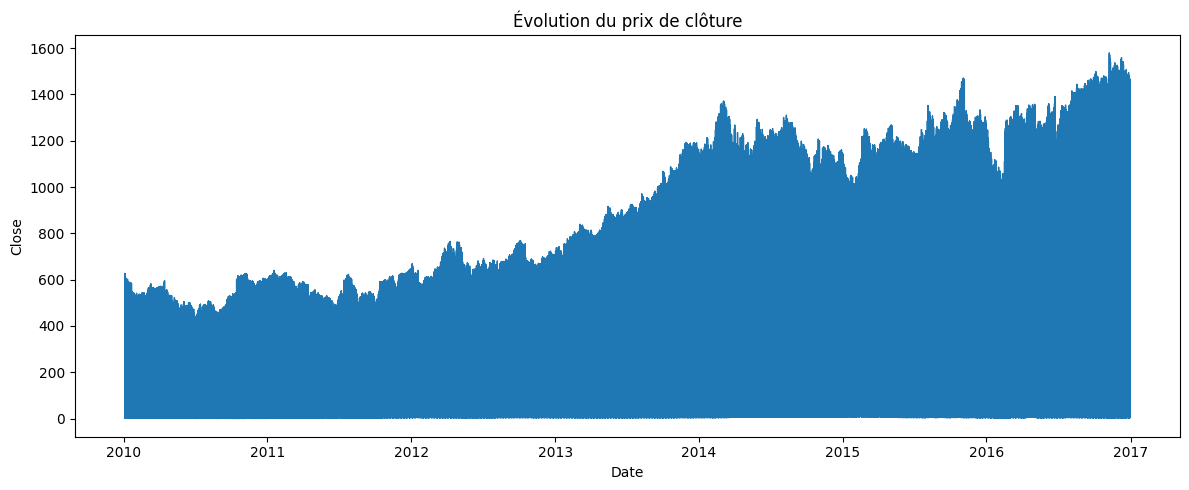

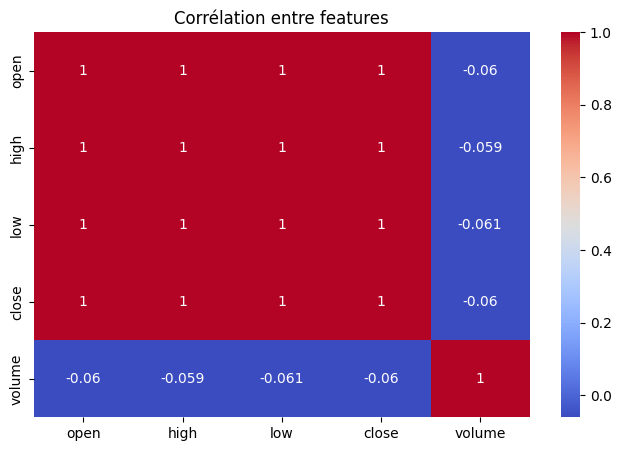

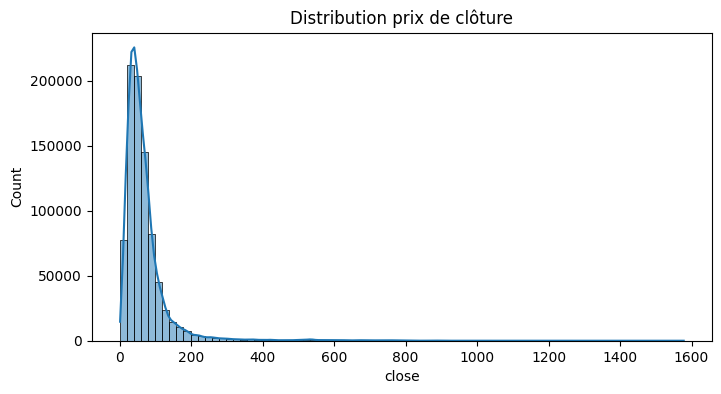

Split → Train: 595,884, Val: 127,690, Test: 127,690
Nombre de configurations à tester: 32

Config 1/32 -> {'batchnorm': False, 'dropout': 0.0, 'hidden': [64, 32], 'lr': 0.001, 'opt': 'Adam', 'patience': 12, 'wd': 0.0}
 → Best val loss (scaled MSE): 6.165534e-05

Config 2/32 -> {'batchnorm': False, 'dropout': 0.0, 'hidden': [64, 32], 'lr': 0.001, 'opt': 'Adam', 'patience': 12, 'wd': 0.0001}
 → Best val loss (scaled MSE): 9.871805e-05

Config 3/32 -> {'batchnorm': False, 'dropout': 0.0, 'hidden': [64, 32], 'lr': 0.0005, 'opt': 'Adam', 'patience': 12, 'wd': 0.0}
 → Best val loss (scaled MSE): 6.088326e-05

Config 4/32 -> {'batchnorm': False, 'dropout': 0.0, 'hidden': [64, 32], 'lr': 0.0005, 'opt': 'Adam', 'patience': 12, 'wd': 0.0001}
 → Best val loss (scaled MSE): 8.946072e-05

Config 5/32 -> {'batchnorm': False, 'dropout': 0.0, 'hidden': [128, 64, 32], 'lr': 0.001, 'opt': 'Adam', 'patience': 12, 'wd': 0.0}
 → Best val loss (scaled MSE): 6.134638e-05

Config 6/32 -> {'batchnorm': False, 

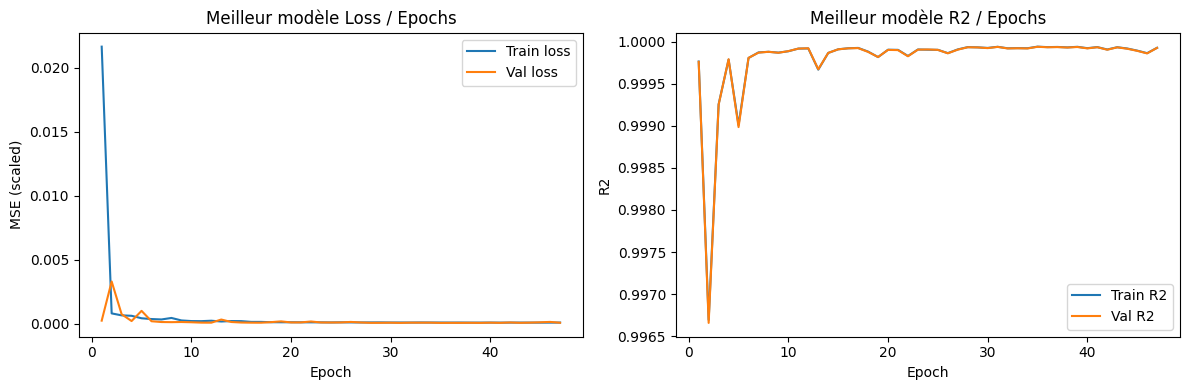

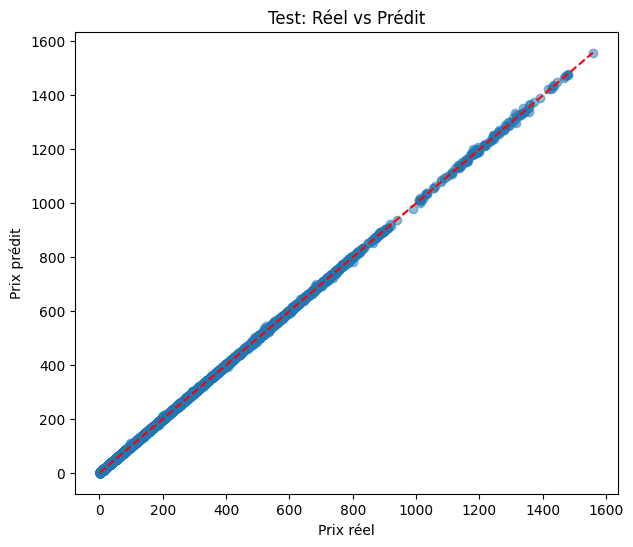

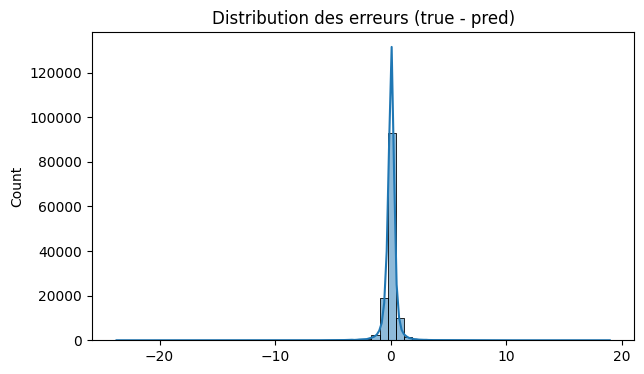

Modèle et scalers sauvegardés dans ./models/

Entraînement du modèle simple (sans régularisation) pour comparaison...
SIMPLE MODEL → R2 = 0.999940 | RMSE = $0.6340


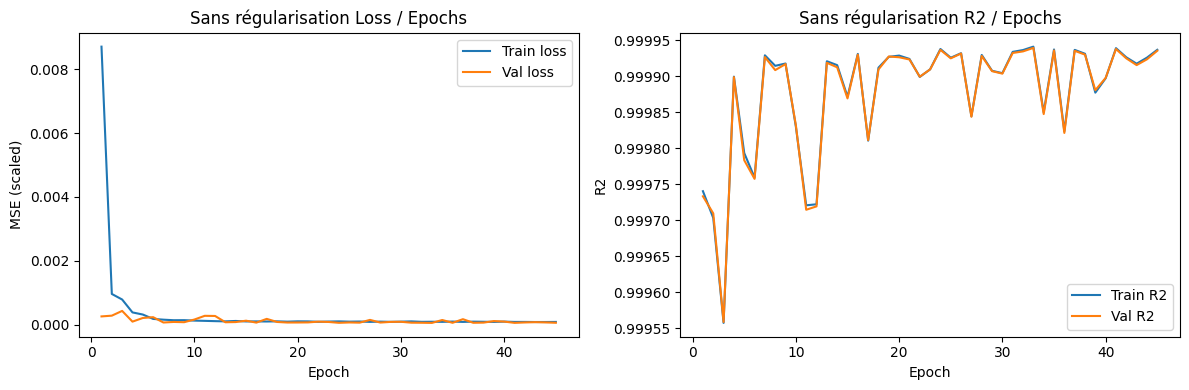

In [1]:
# nyse_regression_complete.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.init import kaiming_uniform_, xavier_uniform_
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm
import copy, warnings, os, random
warnings.filterwarnings('ignore')

# -------------------------
# Réglages & seed
# -------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device → {device} {'(GPU)' if device.type=='cuda' else ''}")

# -------------------------
# 1) CHARGEMENT + CORRECTION
# -------------------------
file_path = '/kaggle/input/nysedataset/prices.csv'  # adapte si nécessaire
df = pd.read_csv(file_path, header=None)
df.columns = ['date', 'symbol', 'open', 'close', 'low', 'high', 'volume']
df['date'] = pd.to_datetime(df['date'], errors='coerce')
numeric_cols = ['open','close','low','high','volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna().reset_index(drop=True)
print(f"Dataset chargé : {len(df):,} lignes | Action sample : {df['symbol'].iloc[0]}")

# -------------------------
# 2) EDA rapide (visu essentielle)
# -------------------------
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['close'], lw=1)
plt.title('Évolution du prix de clôture')
plt.xlabel('Date'); plt.ylabel('Close')
plt.tight_layout(); plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df[['open','high','low','close','volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Corrélation entre features'); plt.show()

# distribution prix
plt.figure(figsize=(8,4))
sns.histplot(df['close'], bins=80, kde=True)
plt.title('Distribution prix de clôture'); plt.show()

# -------------------------
# 3) Préparation des features / scalers
# -------------------------
features = ['open','high','low','volume']
target = 'close'

X = df[features].values
y = df[target].values.reshape(-1,1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y).ravel()

# split
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Split → Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")

# DataLoader
class NYSEDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1,1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_TRAIN = 128
BATCH_VAL   = 512
train_loader = DataLoader(NYSEDataset(X_train, y_train), batch_size=BATCH_TRAIN, shuffle=True, pin_memory=True)
val_loader   = DataLoader(NYSEDataset(X_val, y_val), batch_size=BATCH_VAL, shuffle=False, pin_memory=True)
test_loader  = DataLoader(NYSEDataset(X_test, y_test), batch_size=BATCH_VAL, shuffle=False, pin_memory=True)

# -------------------------
# 4) Modèle (Flexible)
# -------------------------
class RegressionMLP(nn.Module):
    def __init__(self, n_inputs=4, hidden_dims=[128,64,32], dropout=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        prev = n_inputs
        for i,h in enumerate(hidden_dims):
            linear = nn.Linear(prev, h)
            kaiming_uniform_(linear.weight, nonlinearity='relu')
            layers.append(linear)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout>0:
                layers.append(nn.Dropout(dropout))
            prev = h
        out = nn.Linear(prev, 1)
        xavier_uniform_(out.weight)
        layers.append(out)
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

# -------------------------
# 5) EarlyStopping helper
# -------------------------
class EarlyStopping:
    def __init__(self, patience=12, min_delta=1e-6, verbose=False):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.verbose = verbose
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            if self.verbose:
                print(f"  Nouveau best val loss: {val_loss:.6e}")
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.verbose:
                    print("  EarlyStopping déclenché.")
                return True
        return False

# -------------------------
# 6) Fonction d'entraînement par configuration (renvoie history + modèle)
# -------------------------
def train_config(params, max_epochs=200, verbose=False):
    model = RegressionMLP(n_inputs=X_train.shape[1],
                          hidden_dims=params['hidden'],
                          dropout=params.get('dropout', 0.0),
                          use_batchnorm=params.get('batchnorm', False)).to(device)
    optimizer = getattr(optim, params.get('opt','Adam'))(model.parameters(), lr=params['lr'], weight_decay=params.get('wd', 0.0))
    criterion = nn.MSELoss()
    early = EarlyStopping(patience=params.get('patience', 12), min_delta=1e-7, verbose=False)
    
    history = {'train_loss': [], 'val_loss': [], 'train_r2': [], 'val_r2': []}
    
    # Precompute full val X,y as tensors (for speed)
    val_X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_y_tensor = torch.tensor(y_val.reshape(-1,1), dtype=torch.float32).to(device)
    train_X_tensor_full = torch.tensor(X_train, dtype=torch.float32).to(device)
    train_y_tensor_full = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32).to(device)
    
    for epoch in range(1, max_epochs+1):
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # Eval train (full) & val (full)
        model.eval()
        with torch.no_grad():
            train_pred = model(train_X_tensor_full).cpu().numpy().flatten()
            train_true = y_train  # scaled
            # transform to original for r2
            train_pred_orig = scaler_y.inverse_transform(train_pred.reshape(-1,1)).flatten()
            train_true_orig = scaler_y.inverse_transform(train_true.reshape(-1,1)).flatten()
            train_r2 = r2_score(train_true_orig, train_pred_orig)
            
            val_pred = model(val_X_tensor).cpu().numpy().flatten()
            val_true = y_val
            val_pred_orig = scaler_y.inverse_transform(val_pred.reshape(-1,1)).flatten()
            val_true_orig = scaler_y.inverse_transform(val_true.reshape(-1,1)).flatten()
            val_loss = float(criterion(torch.tensor(val_pred).reshape(-1,1), torch.tensor(val_true).reshape(-1,1)).item())
            val_r2 = r2_score(val_true_orig, val_pred_orig)
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(val_loss)
        history['train_r2'].append(train_r2)
        history['val_r2'].append(val_r2)
        
        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train loss {epoch_train_loss:.6e} | Val loss {val_loss:.6e} | Val R2 {val_r2:.5f}")
        
        # Early stopping check (we use val_loss on scaled values)
        stop = early.step(val_loss, model)
        if stop:
            if verbose:
                print(f"Stopped at epoch {epoch}")
            break
    
    # load best
    if early.best_state is not None:
        model.load_state_dict(early.best_state)
    return model, history, early.best_loss

# -------------------------
# 7) GridSearch (réduit et raisonnable)
# -------------------------
param_grid = {
    'hidden': [
        [64,32],
        [128,64,32]
    ],
    'lr': [1e-3, 5e-4],
    'opt': ['Adam'],
    'dropout': [0.0, 0.2],
    'wd': [0.0, 1e-4],
    'batchnorm': [False, True],
    'patience': [12]
}

grid = list(ParameterGrid(param_grid))
print(f"Nombre de configurations à tester: {len(grid)}")

results = []
for i, params in enumerate(grid, 1):
    print(f"\nConfig {i}/{len(grid)} -> {params}")
    model, history, best_val_loss = train_config(params, max_epochs=200, verbose=False)
    results.append({'params': params, 'model': model, 'history': history, 'val_loss': best_val_loss})
    print(f" → Best val loss (scaled MSE): {best_val_loss:.6e}")

# Choix du meilleur (selon val_loss)
best_entry = min(results, key=lambda r: r['val_loss'])
best_params = best_entry['params']
best_model = best_entry['model']
best_history = best_entry['history']
print("\nMEILLEUR MODELE TROUVÉ:", best_params)
print(f"Best val loss (scaled) = {best_entry['val_loss']:.6e}")

# -------------------------
# 8) Évaluation finale (Test set)
# -------------------------
def evaluate_model(model, X_test, y_test, scaler_y):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        pred_scaled = model(X_tensor).cpu().numpy().flatten()
        pred = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
        true = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    return {'rmse': rmse, 'r2': r2, 'pred': pred, 'true': true}

res_test = evaluate_model(best_model, X_test, y_test, scaler_y)
print(f"\nÉVALUATION SUR TEST → R² = {res_test['r2']:.6f} | RMSE = ${res_test['rmse']:.4f}")

# -------------------------
# 9) Plots : Loss / Epochs et R2 / Epochs (train & val)
# -------------------------
def plot_history(history, title_prefix=''):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train loss')
    plt.plot(epochs, history['val_loss'], label='Val loss')
    plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)'); plt.title(f'{title_prefix} Loss / Epochs')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_r2'], label='Train R2')
    plt.plot(epochs, history['val_r2'], label='Val R2')
    plt.xlabel('Epoch'); plt.ylabel('R2'); plt.title(f'{title_prefix} R2 / Epochs')
    plt.legend()
    plt.tight_layout(); plt.show()

print("\nCourbes du meilleur modèle:")
plot_history(best_history, title_prefix='Meilleur modèle')

# Scatter vrai vs prédit (test)
plt.figure(figsize=(7,6))
plt.scatter(res_test['true'], res_test['pred'], alpha=0.5)
minv, maxv = min(res_test['true'].min(), res_test['pred'].min()), max(res_test['true'].max(), res_test['pred'].max())
plt.plot([minv, maxv], [minv, maxv], 'r--')
plt.xlabel('Prix réel'); plt.ylabel('Prix prédit'); plt.title('Test: Réel vs Prédit')
plt.show()

# Histogramme erreurs
plt.figure(figsize=(7,4))
sns.histplot(res_test['true'] - res_test['pred'], bins=60, kde=True)
plt.title('Distribution des erreurs (true - pred)'); plt.show()

# -------------------------
# 10) Sauvegarde du meilleur modèle + scalers
# -------------------------
os.makedirs('models', exist_ok=True)
torch.save(best_model.state_dict(), 'models/best_nyse_model.pth')
# sauvegarder aussi les scalers pour inference future
import joblib
joblib.dump(scaler_X, 'models/scaler_X.save')
joblib.dump(scaler_y, 'models/scaler_y.save')
print("Modèle et scalers sauvegardés dans ./models/")

# -------------------------
# 11) Comparaison explicite : sans régularisation vs avec (optionnel)
# -------------------------
# Pour tester l'effet de la régularisation, entraîne un modèle identique avec dropout=0, batchnorm=False, wd=0
# (Exécution rapide si tu veux comparer)
simple_params = {'hidden':[64,32], 'lr':1e-3, 'opt':'Adam', 'dropout':0.0, 'wd':0.0, 'batchnorm':False, 'patience':12}
print("\nEntraînement du modèle simple (sans régularisation) pour comparaison...")
simple_model, simple_history, _ = train_config(simple_params, max_epochs=200, verbose=False)
simple_res_test = evaluate_model(simple_model, X_test, y_test, scaler_y)
print(f"SIMPLE MODEL → R2 = {simple_res_test['r2']:.6f} | RMSE = ${simple_res_test['rmse']:.4f}")

# Plot comparaison R2
plot_history(simple_history, title_prefix='Sans régularisation')


In [ ]:
# Redémarre le kernel après ça (clique sur "Restart kernel" ou exécute cette ligne)
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 33.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 281.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 226.4 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 233.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 148.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 362.6 MB/s eta 0:00:00 0:00:01m
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.2
    Uninstalling joblib-1.5.2:
      Successfully uninstalled joblib-1.5.2
  Attemp

In [2]:
!pip install numpy==1.26.4 --force-reinstall
!pip install --upgrade scikit-learn imbalanced-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 79.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.4.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
ydata-profiling 4.17.0 requires scipy<1.16,>=1.4.1, but you have scipy 1.16.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires panda

Device: cuda
Shape initiale: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure



Valeurs manquantes par colonne:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64
Colonnes candidates pour la target: ['Target', 'Failure Type']
Target choisie : Target
Features utilisées: ['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Nombre de classes: 2


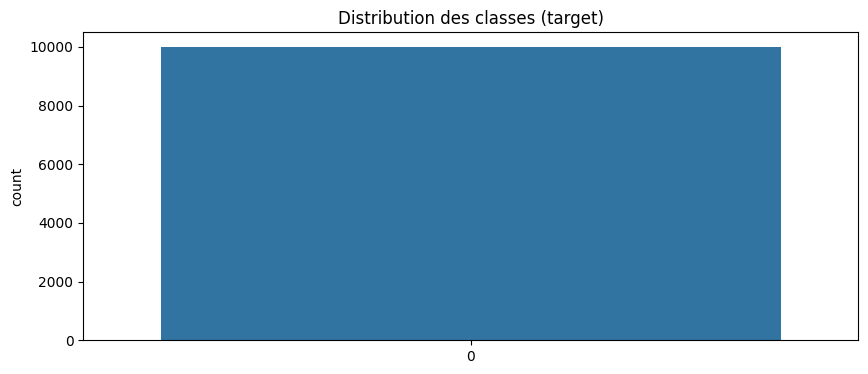

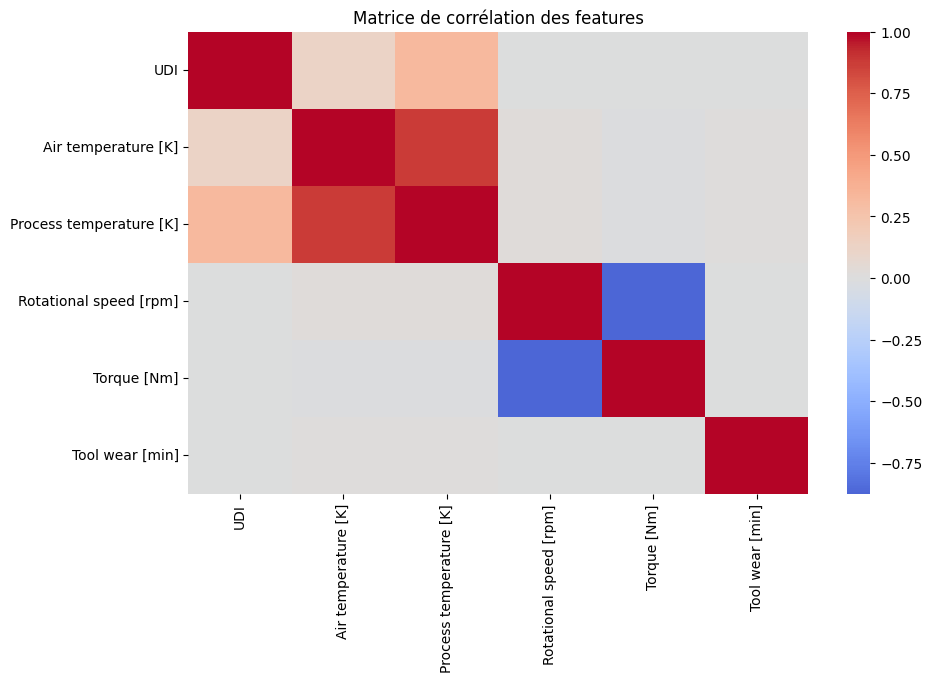

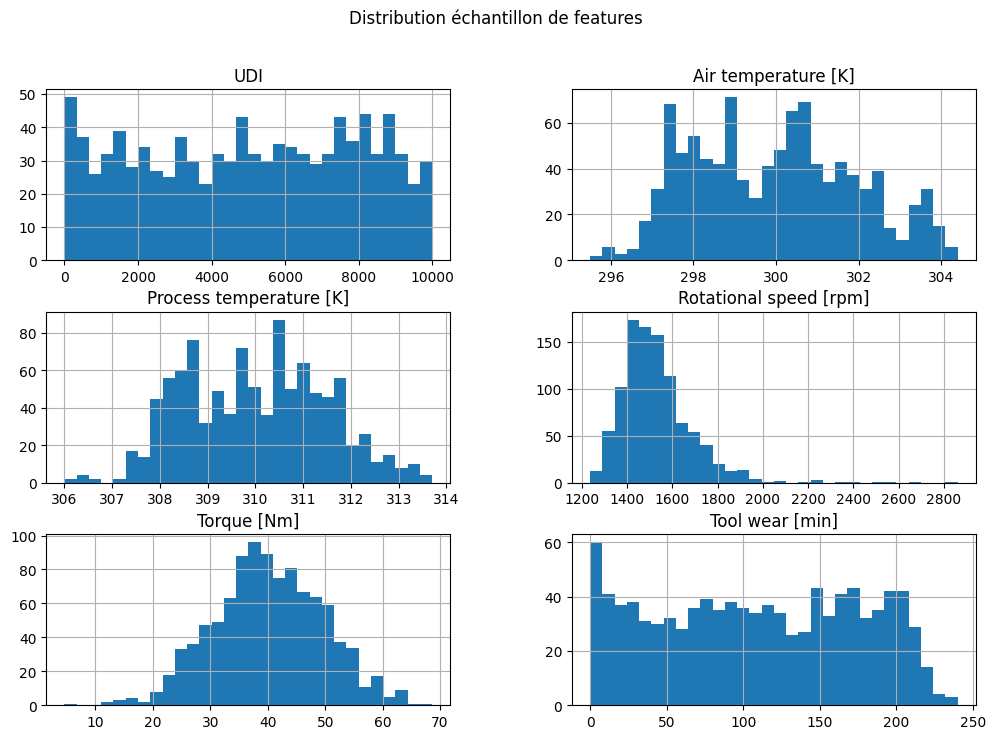

Split -> Train: 7000 Val: 1500 Test: 1500
Distribution classes (train) avant rééq: {np.int64(0): np.int64(6763), np.int64(1): np.int64(237)}
Après SMOTE: (array([0, 1]), array([6763, 6763]))
Nombre de configurations: 216

Config 1/216 -> {'batchnorm': False, 'dropout': 0.1, 'hidden': [32, 16], 'lr': 0.01, 'opt': 'Adam', 'patience': 5, 'wd': 0}
   Best val loss: 0.15735098719596863

Config 2/216 -> {'batchnorm': False, 'dropout': 0.1, 'hidden': [32, 16], 'lr': 0.01, 'opt': 'Adam', 'patience': 5, 'wd': 0.0005}
   Best val loss: 0.15516844391822815

Config 3/216 -> {'batchnorm': False, 'dropout': 0.1, 'hidden': [32, 16], 'lr': 0.01, 'opt': 'SGD', 'patience': 5, 'wd': 0}
   Best val loss: 0.6501405239105225

Config 4/216 -> {'batchnorm': False, 'dropout': 0.1, 'hidden': [32, 16], 'lr': 0.01, 'opt': 'SGD', 'patience': 5, 'wd': 0.0005}
   Best val loss: 0.25934281945228577

Config 5/216 -> {'batchnorm': False, 'dropout': 0.1, 'hidden': [32, 16], 'lr': 0.005, 'opt': 'Adam', 'patience': 5, 'wd

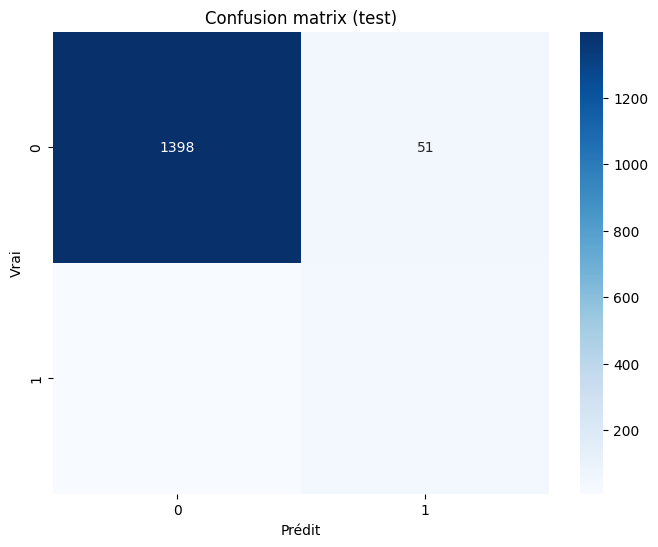


Courbes du meilleur modèle:


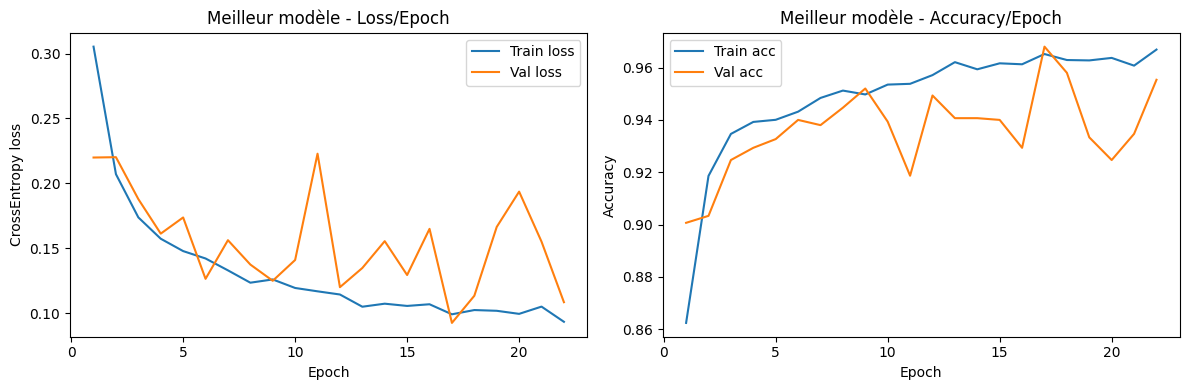

Modèle et artifacts sauvegardés dans ./models/


In [5]:
# predictive_maintenance_multiclass.py
# Solution complète – Multi-class classification (PyTorch)
# Prérequis : torch, sklearn, pandas, matplotlib, seaborn, imblearn, joblib

import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
)

# Optionnel : si tu veux utiliser SMOTE / over-sampling
from imblearn.over_sampling import SMOTE, RandomOverSampler

import joblib
import warnings
warnings.filterwarnings('ignore')

# -------------------------
# Réglages & reproducibility
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# -------------------------
# 1) Chargement du dataset
# -------------------------
# Remplace file_path par le chemin CSV dans ton environnement Kaggle
file_path = '/kaggle/input/machine-predictive/predictive_maintenance.csv'
# si nom différent, adapte

df = pd.read_csv(file_path)
print("Shape initiale:", df.shape)
display(df.head())

# -------------------------
# 2) Préprocessing général
# -------------------------
# 2.1 - Vérifier NaN et types
print("\nValeurs manquantes par colonne:")
print(df.isna().sum())

# Suppression ou imputation si nécessaire (ici on drop les lignes manquantes par sécurité)
df = df.dropna().reset_index(drop=True)

# 2.2 - Sélection des features / target
# Inspecte les colonnes ; ici on suppose qu'il y a une colonne target nommée 'machine_failure' ou 'failure_type' etc.
# Adapte 'target_col' selon le dataset.
possible_targets = [c for c in df.columns if 'failure' in c.lower() or 'target' in c.lower() or 'class' in c.lower()]
print("Colonnes candidates pour la target:", possible_targets)
# Exemple: si la colonne s'appelle 'machine_failure' ou 'failure_type'
# Modifie ci-dessous si nécessaire:
target_col = possible_targets[0] if possible_targets else 'failure'  # adapte si nécessaire
print("Target choisie :", target_col)

# Features = toutes les colonnes numériques sauf target et les identifiants
drop_cols = [target_col]
# enlever colonnes non numériques ou identifiants si présent
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
# on garde cependant la target même si catégorielle
feature_cols = [c for c in df.columns if c not in drop_cols and c not in non_numeric]
print("Features utilisées:", feature_cols)

X = df[feature_cols].copy()
y = df[target_col].copy()

# Si la target est textuelle, la transformer en entiers
if y.dtype == object or y.dtype.name == 'category':
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    print("Classes:", list(le.classes_))
else:
    le = None
    y_enc = y.values

n_classes = len(np.unique(y_enc))
print("Nombre de classes:", n_classes)

# -------------------------
# 3) EDA rapide
# -------------------------
plt.figure(figsize=(10,4))
sns.countplot(y)  # distribution des classes
plt.title('Distribution des classes (target)')
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des features")
plt.show()

# Distribution pour quelques features (prendre un échantillon si grand)
X.sample(1000, random_state=SEED).hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution échantillon de features")
plt.show()

# -------------------------
# 4) Split & scaling
# -------------------------
# Split stratifié pour garder la distribution des classes
X_train, X_temp, y_train, y_temp = train_test_split(X.values, y_enc, test_size=0.30, random_state=SEED, stratify=y_enc)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print("Split -> Train:", X_train.shape[0], "Val:", X_val.shape[0], "Test:", X_test.shape[0])

# Scaling : StandardScaler (fit sur train seulement)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# sauvegarder scaler pour inference future
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler_pm.save')

# -------------------------
# 5) Data augmentation (rééquilibrage)
# -------------------------
# Vérifions l'équilibre
unique, counts = np.unique(y_train, return_counts=True)
print("Distribution classes (train) avant rééq:", dict(zip(unique, counts)))

# Si déséquilibre important, on peut over-sampler (SMOTE ou RandomOverSampler)
use_augmentation = True
if use_augmentation:
    try:
        sm = SMOTE(random_state=SEED)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
        print("Après SMOTE:", np.unique(y_train_res, return_counts=True))
    except Exception as e:
        print("SMOTE failed (peut-être colonnes non adaptées). On utilise RandomOverSampler...")
        ros = RandomOverSampler(random_state=SEED)
        X_train_res, y_train_res = ros.fit_resample(X_train, y_train)
        print("Après RandomOverSampler:", np.unique(y_train_res, return_counts=True))
else:
    X_train_res, y_train_res = X_train, y_train

# -------------------------
# 6) PyTorch Dataset / DataLoader
# -------------------------
class PMDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # labels int pour CrossEntropy
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_TRAIN = 256
BATCH_VAL = 512

train_loader = DataLoader(PMDataset(X_train_res, y_train_res), batch_size=BATCH_TRAIN, shuffle=True, pin_memory=True)
val_loader   = DataLoader(PMDataset(X_val, y_val), batch_size=BATCH_VAL, shuffle=False, pin_memory=True)
test_loader  = DataLoader(PMDataset(X_test, y_test), batch_size=BATCH_VAL, shuffle=False, pin_memory=True)

# -------------------------
# 7) Modèle PyTorch (multi-class)
# -------------------------
class ClassifierMLP(nn.Module):
    def __init__(self, in_dim, hidden_dims=[128,64], dropout=0.2, use_batchnorm=False, n_classes=2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout and dropout>0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))  # logits
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# -------------------------
# 8) EarlyStopping helper
# -------------------------
class EarlyStopping:
    def __init__(self, patience=12, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None
    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
            else:
                return False

# -------------------------
# 9) Fonction d'entraînement (par config)
# -------------------------
def train_config(params, max_epochs=100, verbose=False):
    in_dim = X_train_res.shape[1]
    model = ClassifierMLP(in_dim, hidden_dims=params['hidden'], dropout=params['dropout'],
                          use_batchnorm=params['batchnorm'], n_classes=n_classes).to(device)
    optimizer = getattr(optim, params.get('opt','Adam'))(model.parameters(), lr=params['lr'], weight_decay=params.get('wd',0.0))
    criterion = nn.CrossEntropyLoss()
    early = EarlyStopping(patience=params.get('patience', 12))
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    # Pré-tensors pour val (gain vitesse)
    val_X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_y_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
    
    for epoch in range(1, max_epochs+1):
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
            preds = logits.argmax(dim=1)
            running_corrects += (preds == yb).sum().item()
            total += Xb.size(0)
        epoch_train_loss = running_loss / total
        epoch_train_acc  = running_corrects / total
        
        # Eval sur val
        model.eval()
        with torch.no_grad():
            logits_val = model(val_X_tensor)
            val_loss = criterion(logits_val, val_y_tensor).item()
            val_preds = logits_val.argmax(dim=1).cpu().numpy()
            val_acc = (val_preds == y_val).mean()
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(val_acc)
        
        if verbose and epoch % 10 == 0:
            print(f"Epoch {epoch} | train loss {epoch_train_loss:.4f} train acc {epoch_train_acc:.4f} | val loss {val_loss:.4f} val acc {val_acc:.4f}")
        
        if early.step(val_loss, model):
            if verbose:
                print("EarlyStopping triggered at epoch", epoch)
            break
    
    if early.best_state is not None:
        model.load_state_dict(early.best_state)
    return model, history, early.best_loss

# -------------------------
# 10) GridSearch (réduit raisonnable)
# -------------------------
param_grid = {
    'hidden': [[32,16], [64,32], [256,128,64]],
    'dropout': [0.1, 0.4, 0.5],
    'batchnorm': [False, True],
    'lr': [1e-2, 5e-3, 1e-4],
    'opt': ['Adam', 'SGD'],
    'wd': [0, 5e-4],
    'patience': [5]
}

grid = list(ParameterGrid(param_grid))
print("Nombre de configurations:", len(grid))

results = []
for i, params in enumerate(grid,1):
    print(f"\nConfig {i}/{len(grid)} -> {params}")
    model, history, best_val_loss = train_config(params, max_epochs=100, verbose=False)
    results.append({'params': params, 'model': model, 'history': history, 'val_loss': best_val_loss})
    print("   Best val loss:", best_val_loss)

# choisir meilleur selon val_loss
best_entry = min(results, key=lambda r: r['val_loss'])
best_params = best_entry['params']
best_model  = best_entry['model']
best_history = best_entry['history']
print("\nMeilleure configuration trouvée:", best_params)
print("Best val loss (scaled):", best_entry['val_loss'])

# -------------------------
# 11) Évaluation finale (test)
# -------------------------
def evaluate(model, X_arr, y_arr, scaler=None):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_arr, dtype=torch.float32).to(device)
        logits = model(X_tensor).cpu().numpy()
        preds = np.argmax(logits, axis=1)
    acc = accuracy_score(y_arr, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_arr, preds, average='weighted', zero_division=0)
    cm = confusion_matrix(y_arr, preds)
    return {'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'preds': preds, 'cm': cm}

res_test = evaluate(best_model, X_test, y_test)
res_train = evaluate(best_model, X_train_res, y_train_res)
print("\nPerformance sur Train (après over-sampling):", {k: round(v,4) for k,v in res_train.items() if k!='preds' and k!='cm'})
print("Performance sur Test:", {k: round(v,4) for k,v in res_test.items() if k!='preds' and k!='cm'})

# Classification report (test)
print("\nClassification report (test):")
print(classification_report(y_test, res_test['preds'], zero_division=0, digits=4))

# Afficher matrice de confusion
plt.figure(figsize=(8,6))
sns.heatmap(res_test['cm'], annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix (test)')
plt.xlabel('Prédit'); plt.ylabel('Vrai')
plt.show()

# -------------------------
# 12) Plots Loss / Epochs and Accuracy / Epochs
# -------------------------
def plot_history(history, title='Historique'):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train loss')
    plt.plot(epochs, history['val_loss'], label='Val loss')
    plt.xlabel('Epoch'); plt.ylabel('CrossEntropy loss'); plt.title(title + ' - Loss/Epoch')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train acc')
    plt.plot(epochs, history['val_acc'], label='Val acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(title + ' - Accuracy/Epoch')
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nCourbes du meilleur modèle:")
plot_history(best_history, title='Meilleur modèle')

# -------------------------
# 13) Sauvegarde modèle & label encoder
# -------------------------
torch.save(best_model.state_dict(), 'models/best_pm_model.pth')
if le is not None:
    joblib.dump(le, 'models/label_encoder_pm.save')
print("Modèle et artifacts sauvegardés dans ./models/")

# -------------------------
# 14) Comparaison : appliquer régularisations (optionnel)
# -------------------------
# Tu peux maintenant comparer le modèle sans régularisation et avec (dropout, batchnorm, weight decay).
# Par exemple, entraîne un modèle simple (dropout=0, batchnorm=False, wd=0) et compare metrics.